# HistoMap Tutorial: Mapping Annotations to Visium HD Data

## Introduction

This tutorial demonstrates how to use the HistoMap package to map histological annotations from QuPath onto Visium HD bins and generate an annotation map for downstream analysis.

### Why Use HistoMap with Visium HD?

Visium HD data provides gene expression at high spatial resolution (2–16 µm bins), making it essential to accurately assign each bin to its histological context. HistoMap allows you to:

1. Import tissue annotations from pathology tools like QuPath
2. Map these annotations onto Visium HD bins at your chosen resolution
3. Integrate histological features with gene expression data
4. Perform region-specific analyses (differential expression, spatial statistics, etc.)

## Tutorial Overview

In this tutorial, we will:

1. Load Visium HD data and set the bin resolution
2. Create a HistoMap object with histological annotations
3. Visualize annotations and compute bin-level overlaps
4. Generate a comprehensive annotation map
5. Export the processed data for downstream analysis

> **Tip:** If you want to filter background bins first, run the [Tissue Detection tutorial](1_Tissue_detection_HD.ipynb) before this one.

Let's begin!

## 1. Setting up the Environment

First, let's import the necessary libraries and configure our environment. We'll suppress warnings to keep our notebook clean and focused.

In [1]:
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Import required libraries
import spatialdata  # For handling spatial data objects
import spatialdata_io  # For reading spatial data formats
import histomaptx as hm  # Main package for annotation integration
import matplotlib.pyplot as plt  # For visualization

# Set figure size for better visualization
plt.rcParams['figure.figsize'] = [12, 10]

## 2. Creating the HistoMap Object

We need three key inputs to create a HistoMap object:

| Input | Description |
|-------|-------------|
| `visium_path` | Path to the Space Ranger output folder |
| `annotation_file` | Histological annotation GeoJSON exported from QuPath |
| `full_res_image` | Full-resolution image used for annotation and Space Ranger |

### 2.1 Set Paths

In [2]:
# Path to your Visium dataset folder (containing the SpaceRanger output)
visium_path = "/home/croizer/Documents/01_Ressources/02_Public_Visium/VisiumHD_colon"

# Path to QuPath annotation GeoJSON file
annotation_file = "/home/croizer/Documents/03_Paper/05_Histomap/colon/tissue_detect.geojson.gz"

# Path to full resolution TIFF image (the one used for annotation and SpaceRanger)
full_res_image = "/home/croizer/Documents/01_Ressources/02_Public_Visium/VisiumHD_colon/Visium_HD_Human_Colon_Cancer_tissue_image.btf"

In [3]:
# Load the Visium data using spatialdata_io
visium = spatialdata_io.visium_hd(visium_path, dataset_id="Visium_HD_Human_Colon_Cancer")

### 2.2 Choose Resolution

Visium HD data is available at three bin sizes. Choose the resolution that best suits your analysis:

| Resolution | Bin size | Best for |
|------------|----------|---------- |
| `02` | 2 µm | Subcellular / single-cell resolution |
| `08` | 8 µm | Cellular resolution |
| `16` | 16 µm | Tissue-level analysis, faster processing |

> **Note:** Smaller bins yield higher spatial resolution but significantly increase computation time. For initial exploration, `16` µm is recommended.

In [4]:
resolution = '16'

## 3. Loading Histological Annotations

Now load the main histological annotations (tumor, stroma, necrosis, etc.) as a HistoMap object.

### 3.1 Create the HistoMap Object

For large whole-slide images, it is common practice to separate the tissue detection mask and the histological annotations into two independent GeoJSON files exported from QuPath. This keeps each file manageable and avoids polygon complexity issues.

Here we load the annotation GeoJSON and create a new HistoMap object that will be used for the rest of this tutorial.

> **Note:** If your GeoJSON file contains very large polygons and fails to load, you may need to set the environment variable `OGR_GEOJSON_MAX_OBJ_SIZE` to remove the size limit (e.g., `os.environ["OGR_GEOJSON_MAX_OBJ_SIZE"] = "0"`).

In [5]:
# Path to QuPath annotation GeoJSON file
annotation_file = "/home/croizer/Documents/03_Paper/05_Histomap/colon/full_annot_stroma_debris.geojson.gz"


In [6]:
# Create a HistoMap object by combining the annotation file, Visium data, and the full resolution image
histomap = hm.HistoMap(annotation_file, visium, full_res_image, visium_type='visium_hd', bin_size=int(resolution))

# Display information about the HistoMap object
print(histomap)

HistoMap Object

--------Annotation--------
📂 Annotation file used: /home/croizer/Documents/03_Paper/05_Histomap/colon/full_annot_stroma_debris.geojson.gz
📂 Full resolution image used: /home/croizer/Documents/01_Ressources/02_Public_Visium/VisiumHD_colon/Visium_HD_Human_Colon_Cancer_tissue_image.btf
🔢 Number of annotations present: 11
🏷 Annotations: Debris, Muscle, Muscle_muqueuse, Necrosis, Normal, Stroma_normal, Stroma_tumor, Tumor, blood, demosplastic_stroma, loose_stroma
🏷 Activated annotations: Normal, Muscle, Necrosis, Tumor, blood, Muscle_muqueuse, demosplastic_stroma, Debris, Stroma_normal, loose_stroma, Stroma_tumor
🏷 Disabled annotations: 

-------Spatial Data--------
Type is visium_hd

SpatialData object
├── Images
│     ├── 'Visium_HD_Human_Colon_Cancer_full_image': DataTree[cyx] (3, 48740, 75250), (3, 24370, 37625), (3, 12185, 18812), (3, 6092, 9406), (3, 3046, 4703)
│     ├── 'Visium_HD_Human_Colon_Cancer_hires_image': DataArray[cyx] (3, 3886, 6000)
│     └── 'Visium_HD_H

### 3.2 Visualize Annotations

Before computing overlaps, let's visualize the annotations to confirm they are correctly aligned with the tissue section. This helps catch any coordinate mismatch between the GeoJSON and the Visium image early.

### 3.3 Compute Annotation Overlaps

A key feature of HistoMap is the ability to quantify how much each Visium HD bin overlaps with each annotation region. This provides a precise, continuous measure of annotation coverage per bin (expressed as a percentage from 0 to 100).

Computing overlaps at high resolution (e.g., 2 µm bins) can be computationally intensive — consider using a coarser resolution for initial exploration.

In [8]:
histomap.compute_annotation_overlap('all')


Starting calculating overlap
1/11 layer processed: Debris
Intersecting spots: 2604
2/11 layer processed: Muscle
Intersecting spots: 8921
3/11 layer processed: Muscle_muqueuse
Intersecting spots: 1127
4/11 layer processed: Necrosis
Intersecting spots: 603
5/11 layer processed: Normal
Intersecting spots: 12908
6/11 layer processed: Stroma_normal
Intersecting spots: 15360
7/11 layer processed: Stroma_tumor
Intersecting spots: 58736
8/11 layer processed: Tumor
Intersecting spots: 56879
9/11 layer processed: blood
Intersecting spots: 4446
10/11 layer processed: demosplastic_stroma
Intersecting spots: 34296
11/11 layer processed: loose_stroma
Intersecting spots: 7880
Updated 'Annotation_positive' for 'Normal' with threshold 50%.
Updated 'Annotation_positive' for 'Muscle' with threshold 50%.
Updated 'Annotation_positive' for 'Necrosis' with threshold 50%.
Updated 'Annotation_positive' for 'Tumor' with threshold 50%.
Updated 'Annotation_positive' for 'blood' with threshold 50%.
Updated 'Annota

INFO     Using 'datashader' backend with 'mean' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                
INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     


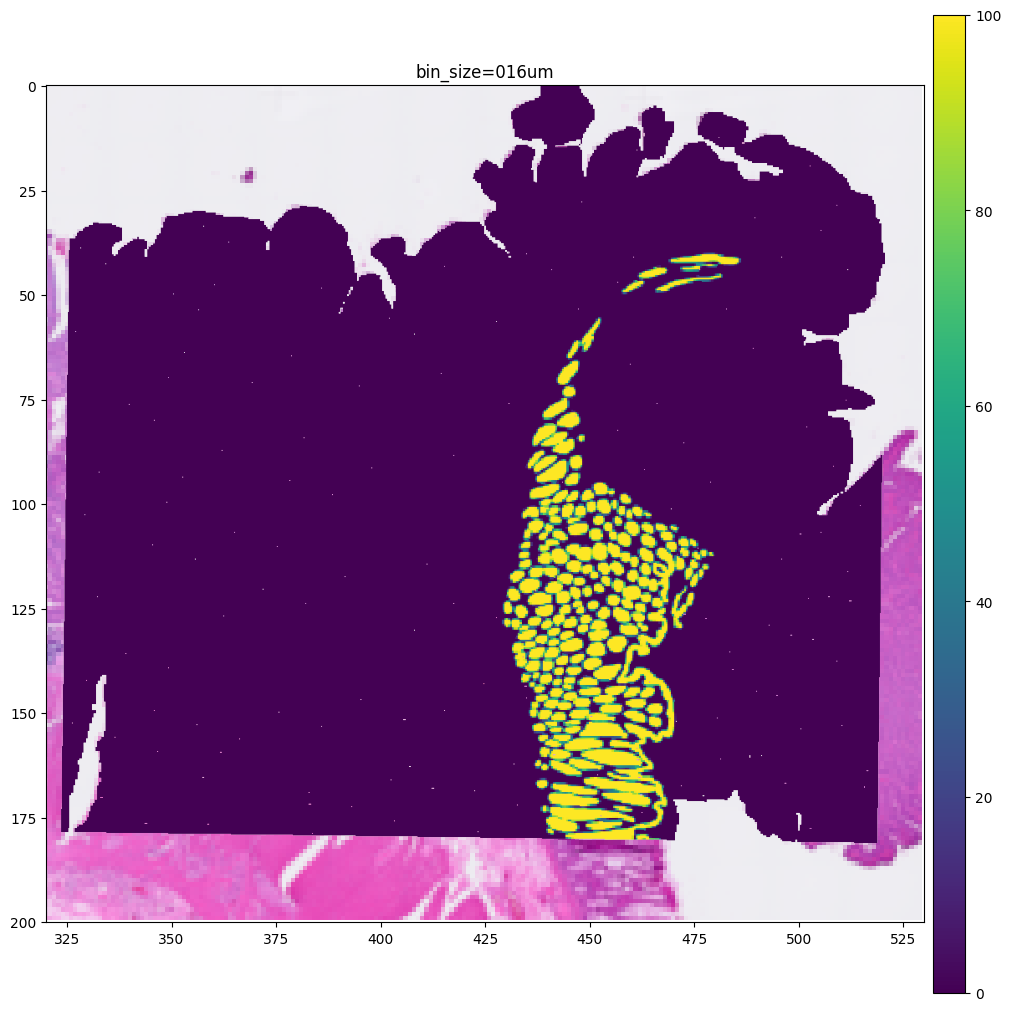

In [9]:
# Visualize the overlap of a specific annotation ('Normal') on the tissue section
# xcoords and ycoords define the region of interest in bin coordinates
hm.plot_annotation_overlay(histomap, annotation='Normal', xcoords=(320, 530), ycoords=(0, 200))


INFO     Using 'datashader' backend with 'mean' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                
INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     


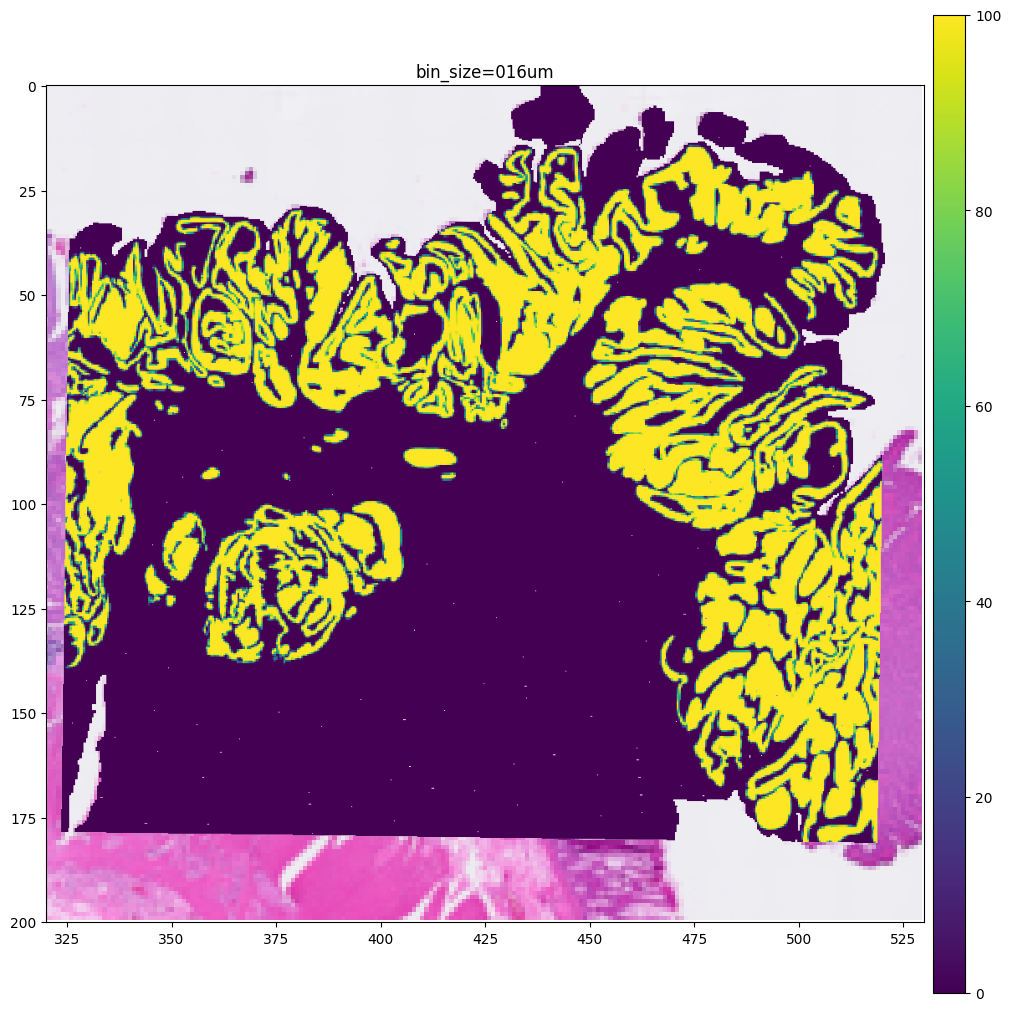

In [10]:
# Same overlay visualization for the 'Tumor' annotation
# Comparing multiple annotations side by side helps verify annotation coverage
hm.plot_annotation_overlay(histomap, annotation='Tumor', xcoords=(320, 530), ycoords=(0, 200))


### 3.4 Set Annotation Order and Generate the Annotation Map

HistoMap treats annotations as layers processed in a priority order. When a bin overlaps multiple annotations, it is assigned to the one that appears **first** in the order. Rare or small features (e.g., blood vessels) should be placed first so they are not masked by larger regions (e.g., stroma or tumor).

The `generate_annotation_map()` function assigns each bin to a single annotation category based on the overlap percentages and the annotation order:
- By default (`annotate_all=True`): bins that don't meet any positivity threshold are assigned to the annotation with the highest overlap percentage.
- With `annotate_all=False`: such bins are assigned to `None`.

In [11]:
# Display the current annotation priority order
# Annotations higher in the list take precedence when a bin overlaps multiple regions
histomap.display_plot_order()


Current Plot Order:


,Annotation,plot_order
412,Debris,0
228,Muscle,1
403,Muscle_muqueuse,2
237,Necrosis,3
163,Normal,4
431,Stroma_normal,5
433,Stroma_tumor,6
280,Tumor,7
388,blood,8
406,demosplastic_stroma,9


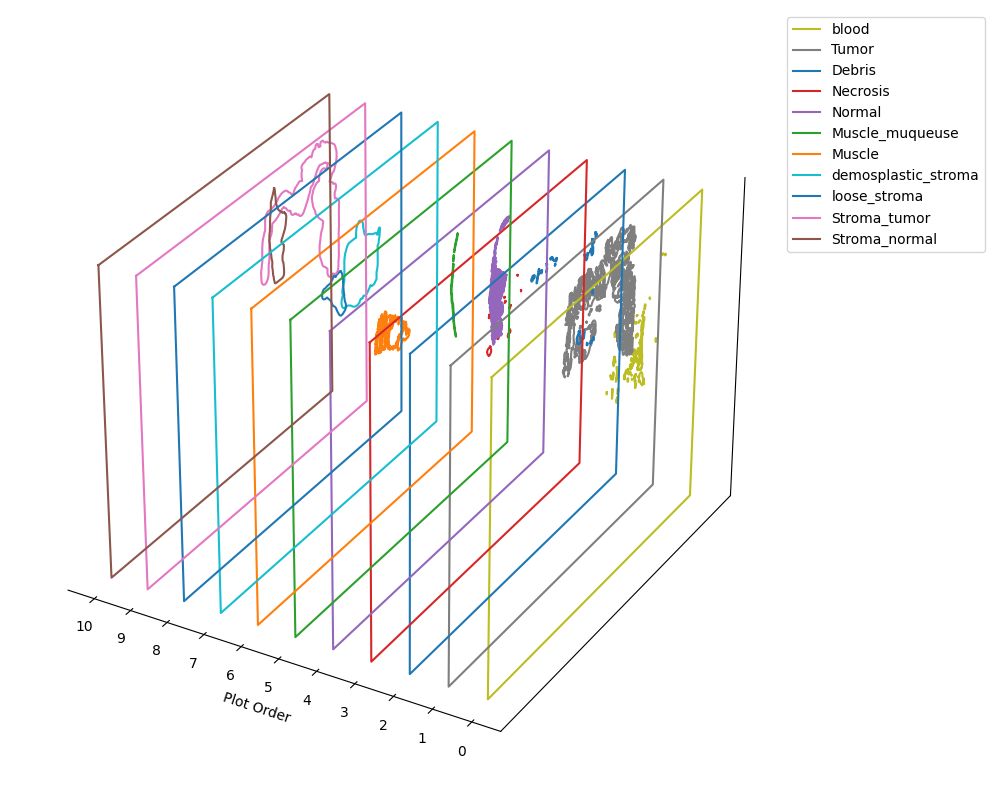

In [14]:
# Plot a diagram showing the current annotation layer order
# Annotations at the top of the diagram take precedence
hm.plot_annotation_order(histomap)

In [15]:
# Set a custom priority order for the annotations
# Small or rare structures (e.g., blood vessels) should come first
# so they are not overridden by larger surrounding regions (e.g., stroma)
histomap.change_plot_order(['blood', 'Tumor', "Debris", 'Necrosis', 'Normal',
                            'Muscle_muqueuse', 'Muscle', 'demosplastic_stroma',
                            'loose_stroma', "Stroma_tumor", 'Stroma_normal'])


Current Plot Order:


In [16]:
# Generate the final annotation map
# Each bin is assigned to a single annotation based on overlap percentage and priority order
# Bins below all positivity thresholds are assigned to the annotation with the highest overlap
histomap.generate_annotation_map()


Annotating remaining spots with the most overlapping annotation...
Annotation map successfully generated


INFO     Using 'datashader' backend with 'mean' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


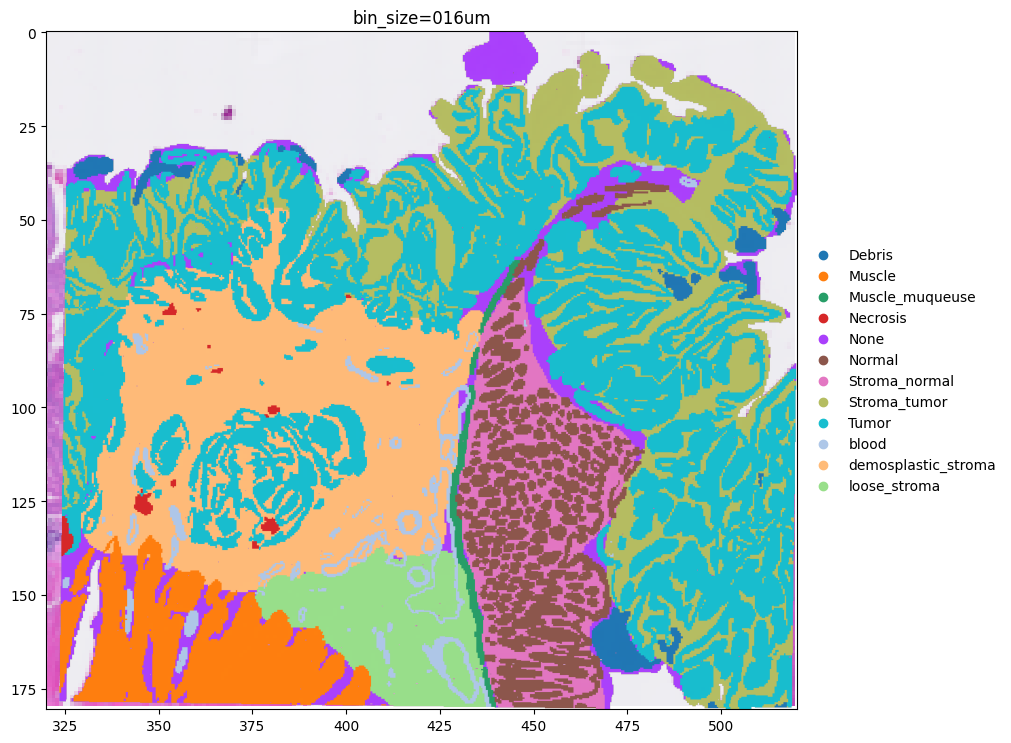

In [17]:
# Plot the final annotation map on the tissue section
# Each bin is colored by its assigned annotation category
hm.plot_annotation_map(histomap, xcoords=(320, 520), ycoords=(0, 180))


In [18]:
# Extract the per-bin metadata table from the HistoMap object
# It contains the annotation map, overlap percentages, and spatial coordinates
df = histomap.visium_spatialdata.tables['square_0' + resolution + 'um'].obs

# Optionally export the metadata to CSV for use in R or other tools
# df.to_csv("/home/croizer/Documents/03_Paper/05_Histomap/colon/annotation_visium_barcode.csv")


In [19]:
# Extract the gene expression table at the chosen resolution
adata = histomap.visium_spatialdata.tables['square_0' + resolution + 'um'].copy()
del histomap  # Free memory — the full SpatialData object is no longer needed

import scanpy as sc

# Standard Scanpy preprocessing pipeline
sc.pp.filter_cells(adata, min_counts=1)          # Remove empty bins
sc.pp.filter_genes(adata, min_counts=1)          # Remove unexpressed genes
sc.pp.normalize_total(adata)                     # Normalize to equal library size
sc.pp.log1p(adata)                               # Log-transform counts

# Select the top 15,000 highly variable genes to reduce dimensionality
sc.pp.highly_variable_genes(adata, n_top_genes=15000)
adata = adata[:, adata.var.highly_variable].copy()

# Scale features, then compute PCA, neighbor graph, and UMAP embedding
sc.pp.scale(adata)
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)


Load the tissue overlap results previously computed in the Tissue Detection tutorial
This CSV contains a 'Positive_overlap' column: percentage of each bin covered by tissue

In [20]:
import pandas as pd


df = pd.read_csv("/home/croizer/Documents/03_Paper/05_Histomap/colon/tissue_overlap_visium_barcode" + resolution + ".csv")
df.index = df['Unnamed: 0']

# Transfer the tissue overlap column to the AnnData obs table, aligning by barcode index
adata.obs['Positive_overlap'] = df['Positive_overlap'].reindex(adata.obs.index)
adata.obs


,in_tissue,array_row,array_col,location_id,region,Normal_overlap,Muscle_overlap,Necrosis_overlap,Tumor_overlap,blood_overlap,Muscle_muqueuse_overlap,demosplastic_stroma_overlap,Debris_overlap,Stroma_normal_overlap,loose_stroma_overlap,Stroma_tumor_overlap,Annotation_map,n_counts,Positive_overlap
s_016um_00052_00082-1,1,52,82,0,Visium_HD_Human_Colon_Cancer_square_016um,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,43.0,0.000000
s_016um_00010_00367-1,1,10,367,1,Visium_HD_Human_Colon_Cancer_square_016um,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,Tumor,4024.0,100.000000
s_016um_00163_00399-1,1,163,399,2,Visium_HD_Human_Colon_Cancer_square_016um,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,Stroma_tumor,1410.0,100.000000
s_016um_00238_00388-1,1,238,388,3,Visium_HD_Human_Colon_Cancer_square_016um,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,Debris,378.0,100.000000
s_016um_00144_00175-1,1,144,175,4,Visium_HD_Human_Colon_Cancer_square_016um,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,demosplastic_stroma,531.0,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s_016um_00375_00231-1,1,375,231,137046,Visium_HD_Human_Colon_Cancer_square_016um,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,1270.0,20.043426
s_016um_00109_00223-1,1,109,223,137047,Visium_HD_Human_Colon_Cancer_square_016um,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,Muscle_muqueuse,820.0,100.000000
s_016um_00039_00175-1,1,39,175,137048,Visium_HD_Human_Colon_Cancer_square_016um,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,loose_stroma,207.0,70.872146
s_016um_00037_00193-1,1,37,193,137049,Visium_HD_Human_Colon_Cancer_square_016um,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,loose_stroma,42.0,37.667322


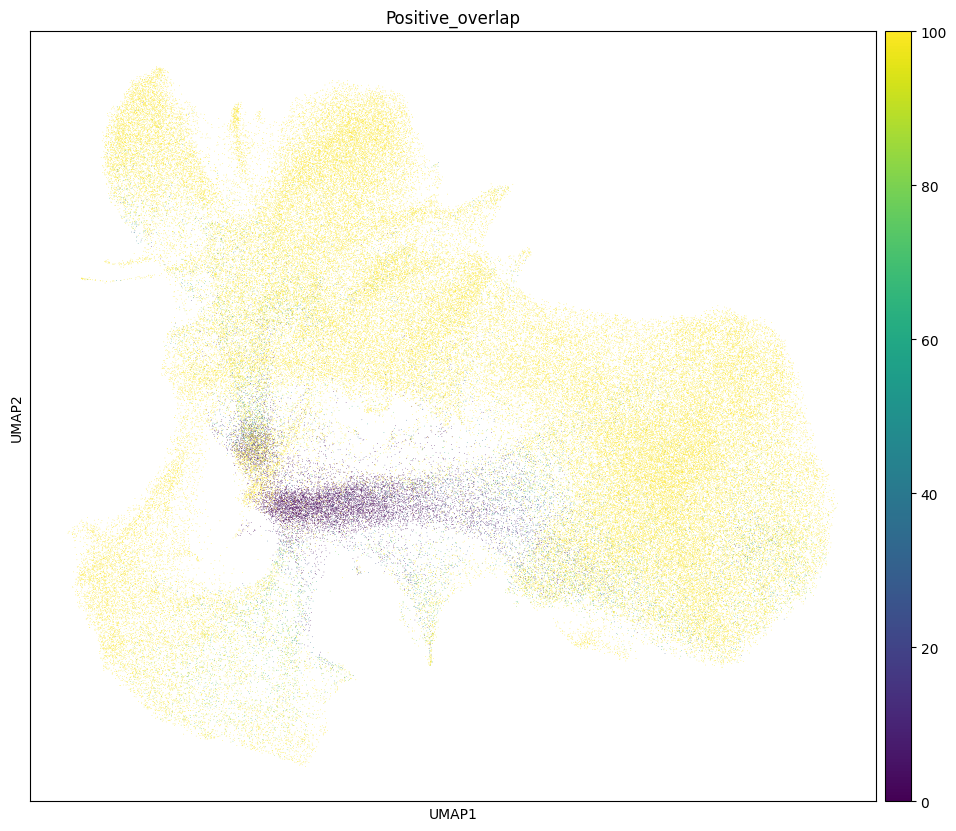

In [21]:
# Visualize tissue coverage in UMAP space
# Bins with low Positive_overlap are likely background or edge bins
sc.pl.umap(adata, color='Positive_overlap')


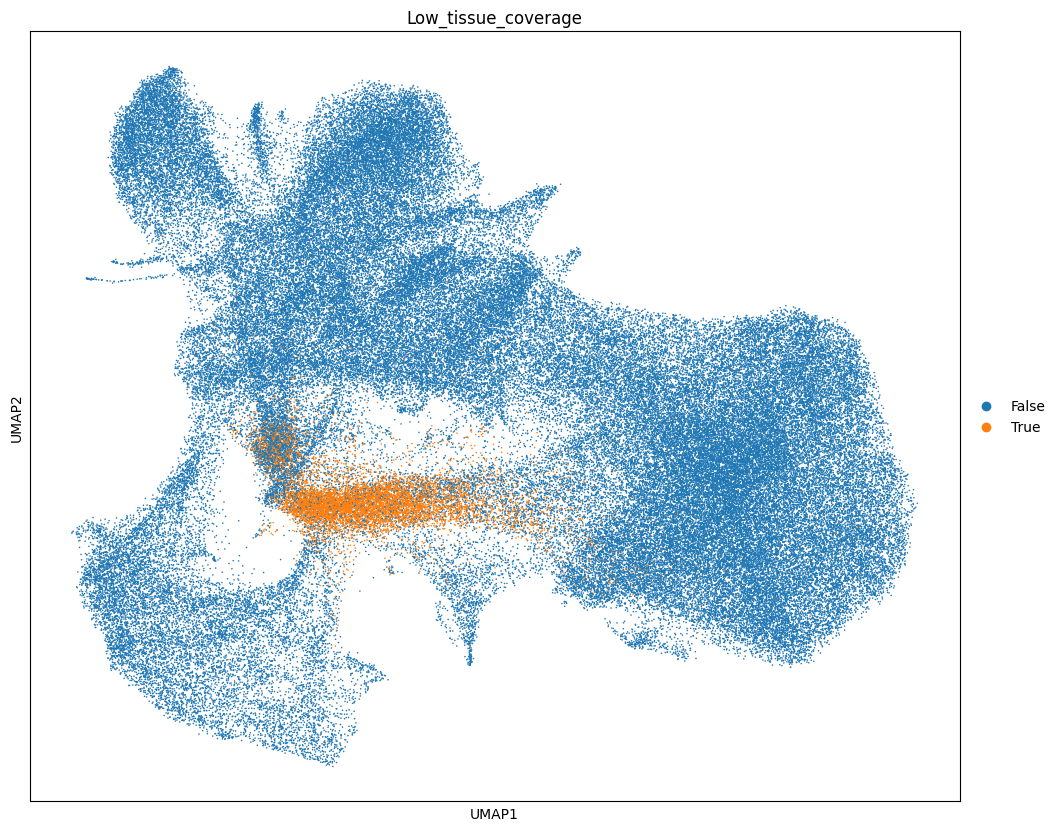

In [22]:
# Flag bins with less than 5% tissue overlap as low-coverage
# These bins may contain mostly background signal and should be excluded
adata.obs['Low_tissue_coverage'] = adata.obs['Positive_overlap'] < 5
sc.pl.umap(adata, color='Low_tissue_coverage', size=5)


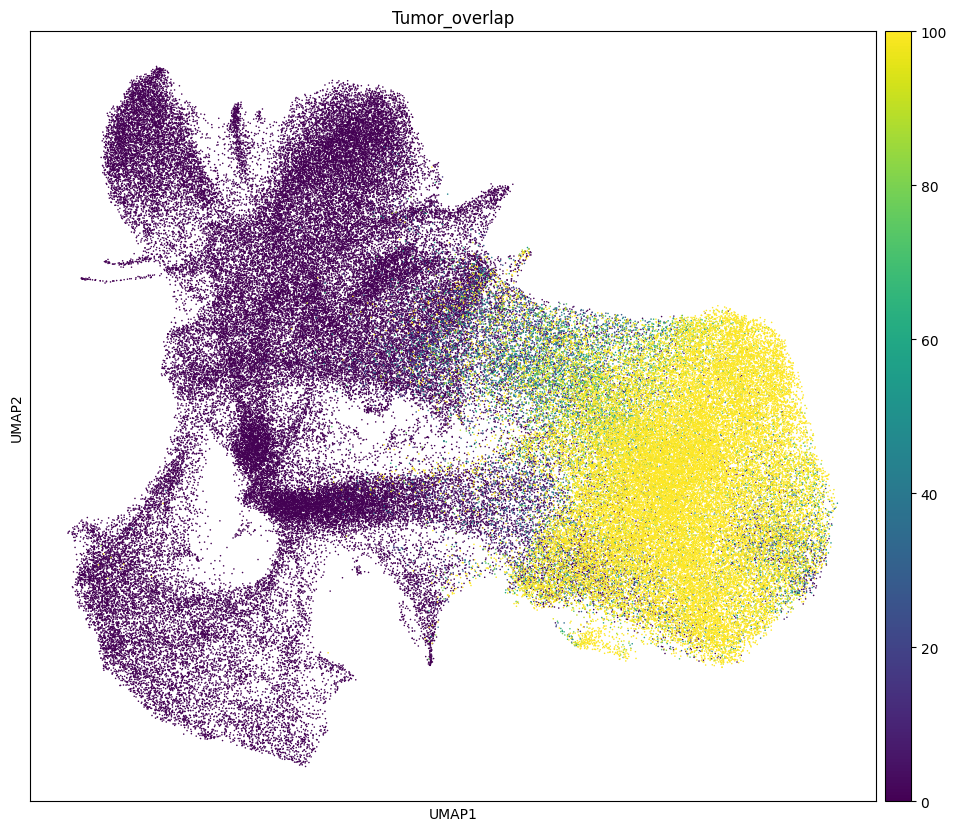

In [23]:
# Visualize the continuous Tumor overlap score in UMAP space
# Bins with high Tumor_overlap should form a distinct cluster
sc.pl.umap(adata, color='Tumor_overlap', size=5)


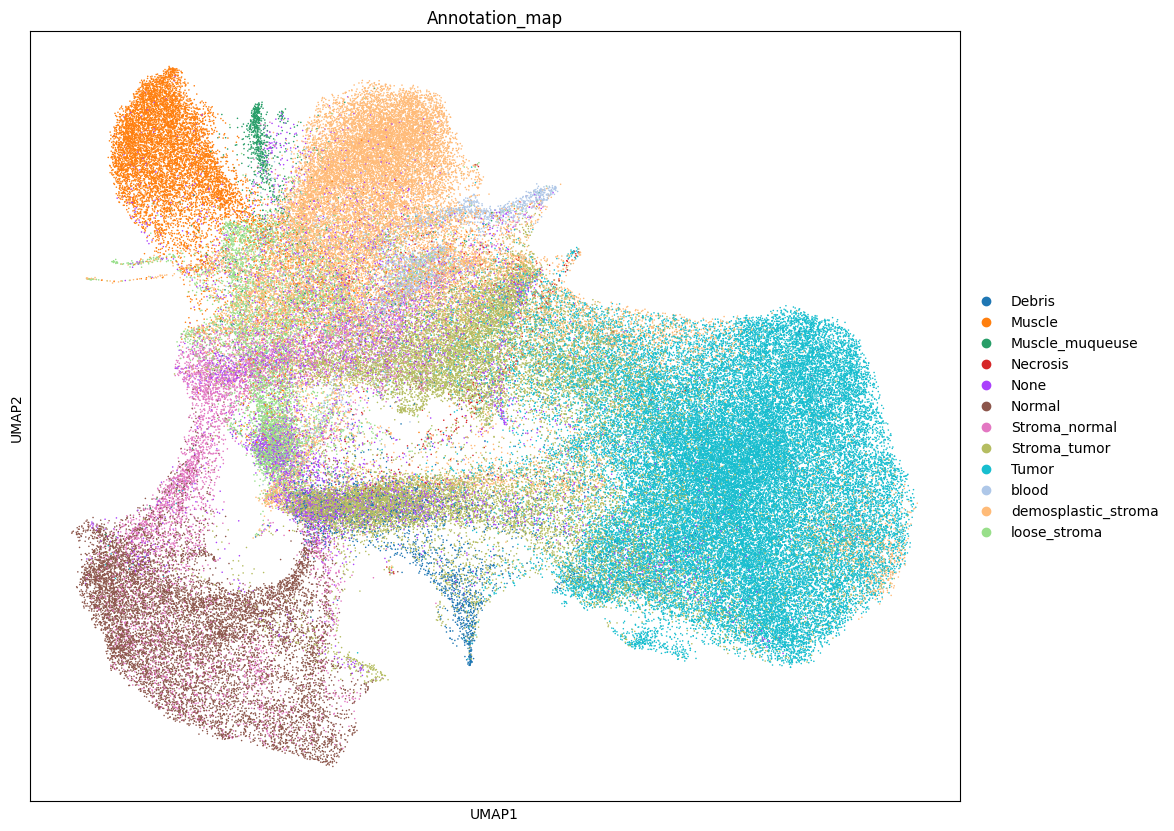

In [24]:
# Visualize the discrete annotation map in UMAP space
# Each bin is colored by its assigned annotation category
sc.pl.umap(adata, color='Annotation_map', size=5)


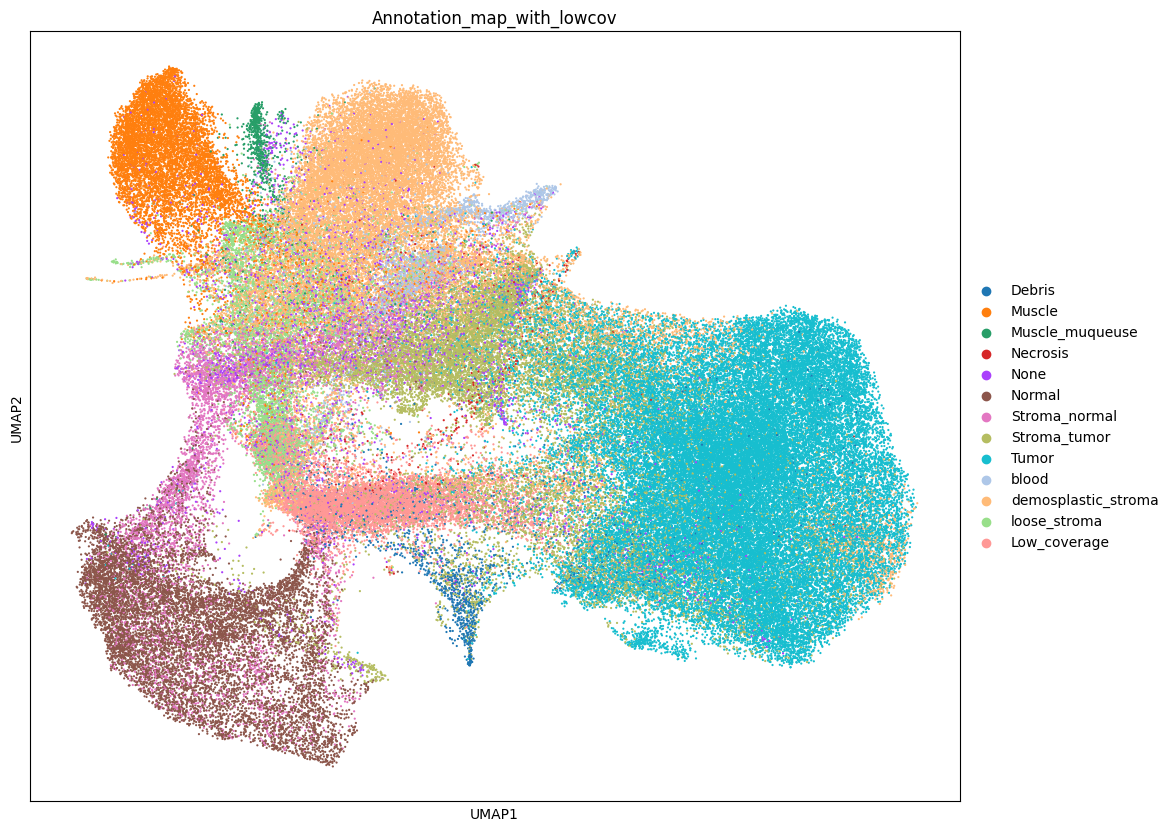

In [25]:
# Create a refined annotation column that incorporates low-coverage bins as a category
# This keeps background bins visible without discarding them from the analysis
adata.obs['Annotation_map_with_lowcov'] = adata.obs['Annotation_map'].copy()

# Add 'Low_coverage' as a valid category
adata.obs['Annotation_map_with_lowcov'] = (
    adata.obs['Annotation_map_with_lowcov']
    .cat.add_categories(['Low_coverage'])
)

# Assign 'Low_coverage' to bins flagged earlier
adata.obs.loc[
    adata.obs['Low_tissue_coverage'],
    'Annotation_map_with_lowcov'
] = 'Low_coverage'

sc.pl.umap(adata, color='Annotation_map_with_lowcov', size=10)


## 4. Exporting and Reloading Results

Once the annotation map has been generated, we can export the annotated AnnData object for downstream analysis (differential expression, spatial statistics, etc.) or reload it later without rerunning the full pipeline.

In [26]:
import scanpy as sc  # Reload scanpy in case this section is run independently


In [27]:
# Save the annotated AnnData object to disk
# This allows you to reload results later without rerunning the full pipeline
adata.write_h5ad('/home/croizer/Documents/03_Paper/05_Histomap/colon/annotated_colon.h5ad')


In [28]:
# Reload the saved AnnData object
adata = sc.read_h5ad('/home/croizer/Documents/03_Paper/05_Histomap/colon/annotated_colon.h5ad')


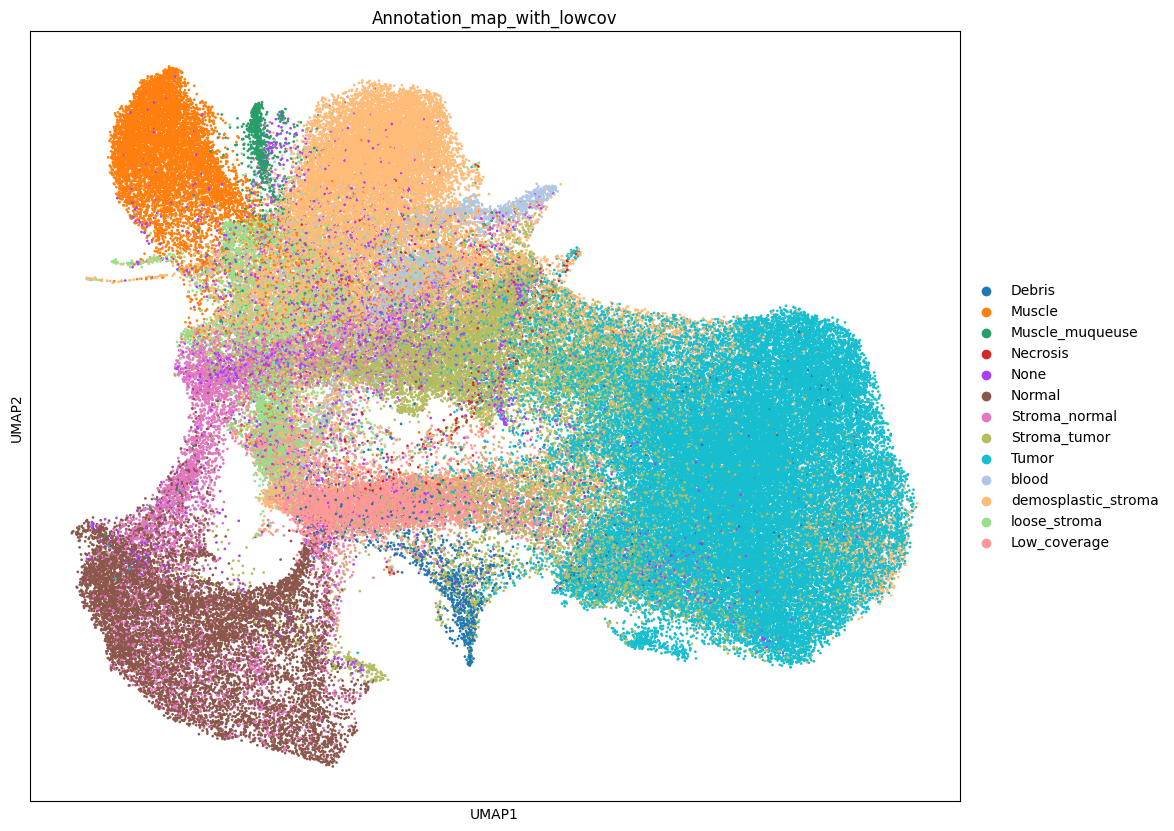

In [29]:
# Visualize the annotation map in UMAP space
# Each point is a bin colored by its assigned annotation category
# 'Low_coverage' bins (low tissue overlap) appear as a distinct group
sc.pl.umap(adata, color='Annotation_map_with_lowcov', size=15)


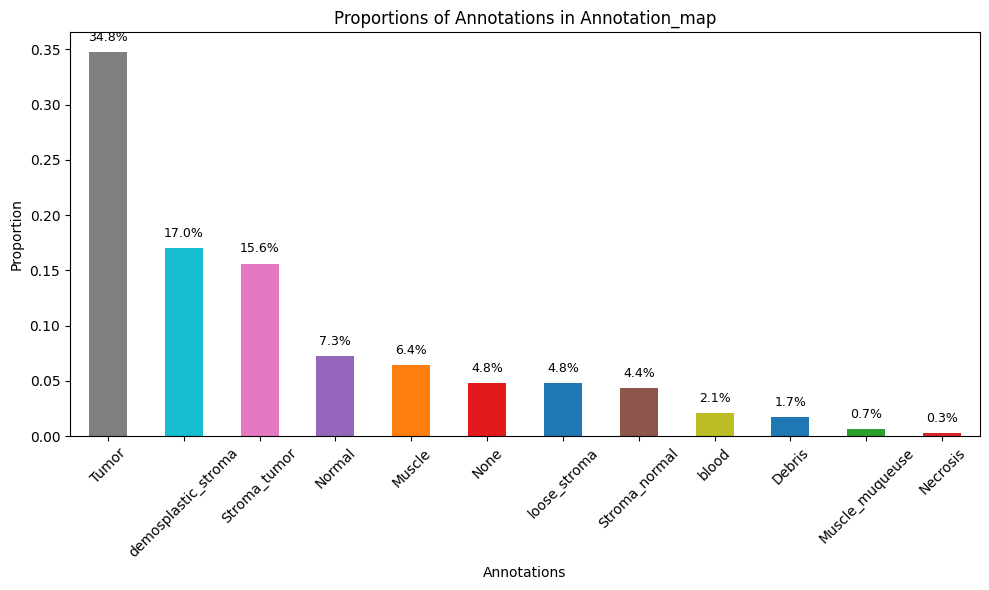

In [ ]:
# Plot the proportion of bins assigned to each annotation category
# Useful for a quick overview of tissue composition
hm.plot_annotation_map_proportions(histomap)
